In [113]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [114]:
df = pd.read_csv('UberDataset.csv')
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


### Data Preprocessing

In [115]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')

In [116]:
# check the data type
df.dtypes

START_DATE     object
END_DATE       object
CATEGORY       object
START          object
STOP           object
MILES         float64
PURPOSE        object
dtype: object

In [117]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'],errors='coerce') 
df['END_DATE'] = pd.to_datetime(df['END_DATE'],errors='coerce') 


In [118]:
# check the information about data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1155 non-null   datetime64[ns]
 1   END_DATE    1155 non-null   datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1156 non-null   float64       
 6   PURPOSE     653 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.3+ KB


In [119]:
# check the null values
df.isnull().sum()

START_DATE      1
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [120]:
# check the overall null values
df.isna().sum().sum()

508

In [121]:
# shape of dataset
df.shape

(1156, 7)

In [122]:
# check the % of null values
pr = (df['PURPOSE'].isna().sum()/df.shape[0])*100
pr

43.5121107266436

In [123]:
# check the overAll % null values
overAll = (df.isna().sum()/df.shape[0])*100
overAll

START_DATE     0.086505
END_DATE       0.086505
CATEGORY       0.086505
START          0.086505
STOP           0.086505
MILES          0.000000
PURPOSE       43.512111
dtype: float64

<Axes: >

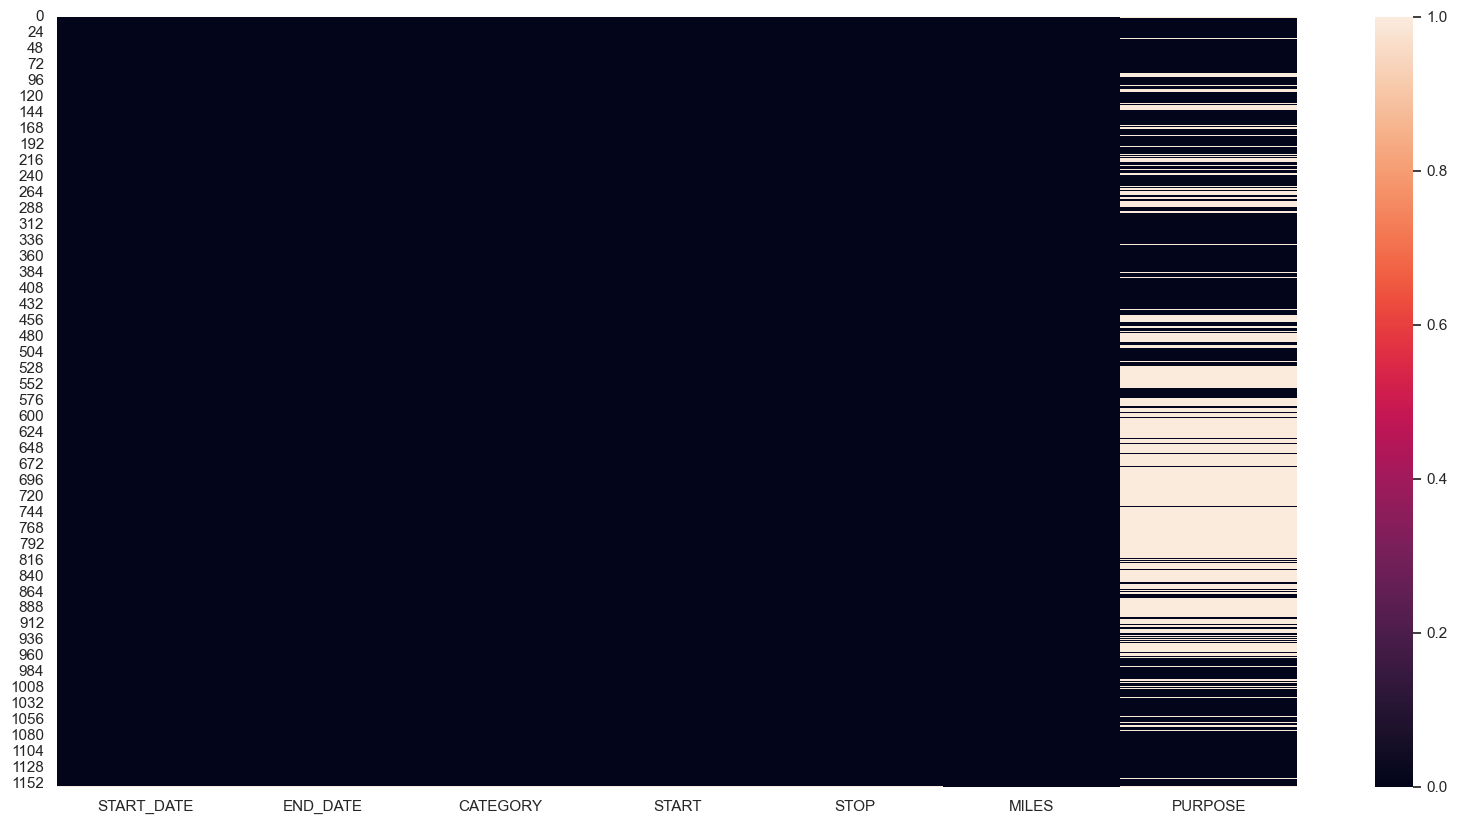

In [124]:
sns.heatmap(df.isnull())

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1155 non-null   datetime64[ns]
 1   END_DATE    1155 non-null   datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1156 non-null   float64       
 6   PURPOSE     653 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.3+ KB


In [126]:
from datetime import datetime
df['date'] = pd.DatetimeIndex(df['START_DATE']).date
df['time'] = pd.DatetimeIndex(df['START_DATE']).hour


In [127]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0


In [128]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0


In [129]:
df['Day-night'] = pd.cut(x=df['time'],bins=[0,10,15,19,24],labels=['Morning','Afternoon','Evening','Night'])

In [130]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,Day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Afternoon


In [131]:
df.dropna(inplace=True)

In [132]:
df.isna().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
date          0
time          0
Day-night     0
dtype: int64

In [133]:
df.shape

(640, 10)

In [134]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'date', 'time', 'Day-night'],
      dtype='object')

Text(0.5, 1.0, 'Count of PURPOSE')

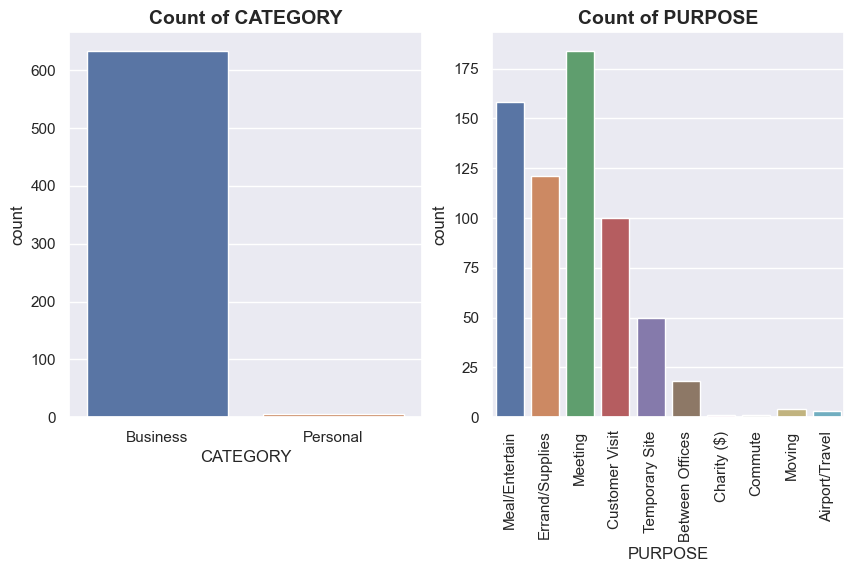

In [135]:
#Count plot for raw case counts
plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='CATEGORY')
plt.title('Count of CATEGORY', fontsize=14, fontweight='bold')

plt.subplot(1,2,2)
sns.countplot(data=df, x='PURPOSE')
plt.xticks(rotation=90)
plt.title('Count of PURPOSE', fontsize=14, fontweight='bold')




<Axes: xlabel='Day-night', ylabel='count'>

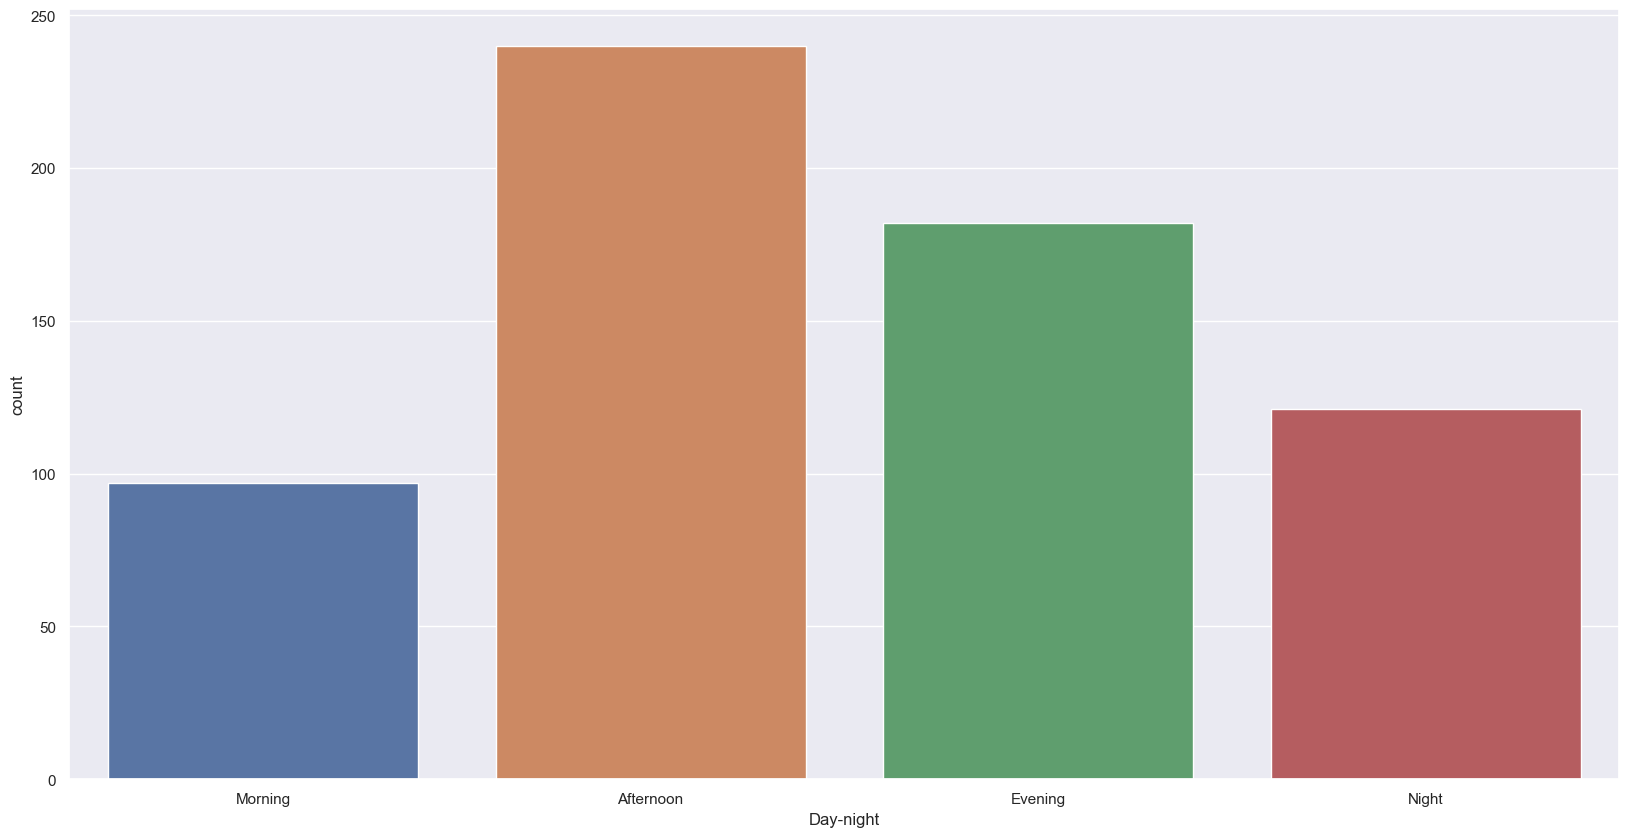

In [136]:
sns.countplot(x=df['Day-night'])

In [137]:
df['Month']=pd.DatetimeIndex(df['START_DATE']).month

month_label={1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April',
 5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug',
 9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}

df['Month']=df.Month.map(month_label)
mon = df.Month.value_counts(sort=False)

In [138]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'date', 'time', 'Day-night', 'Month'],
      dtype='object')

[Text(0.5, 0, 'Months'), Text(0, 0.5, 'VALUE COUNT')]

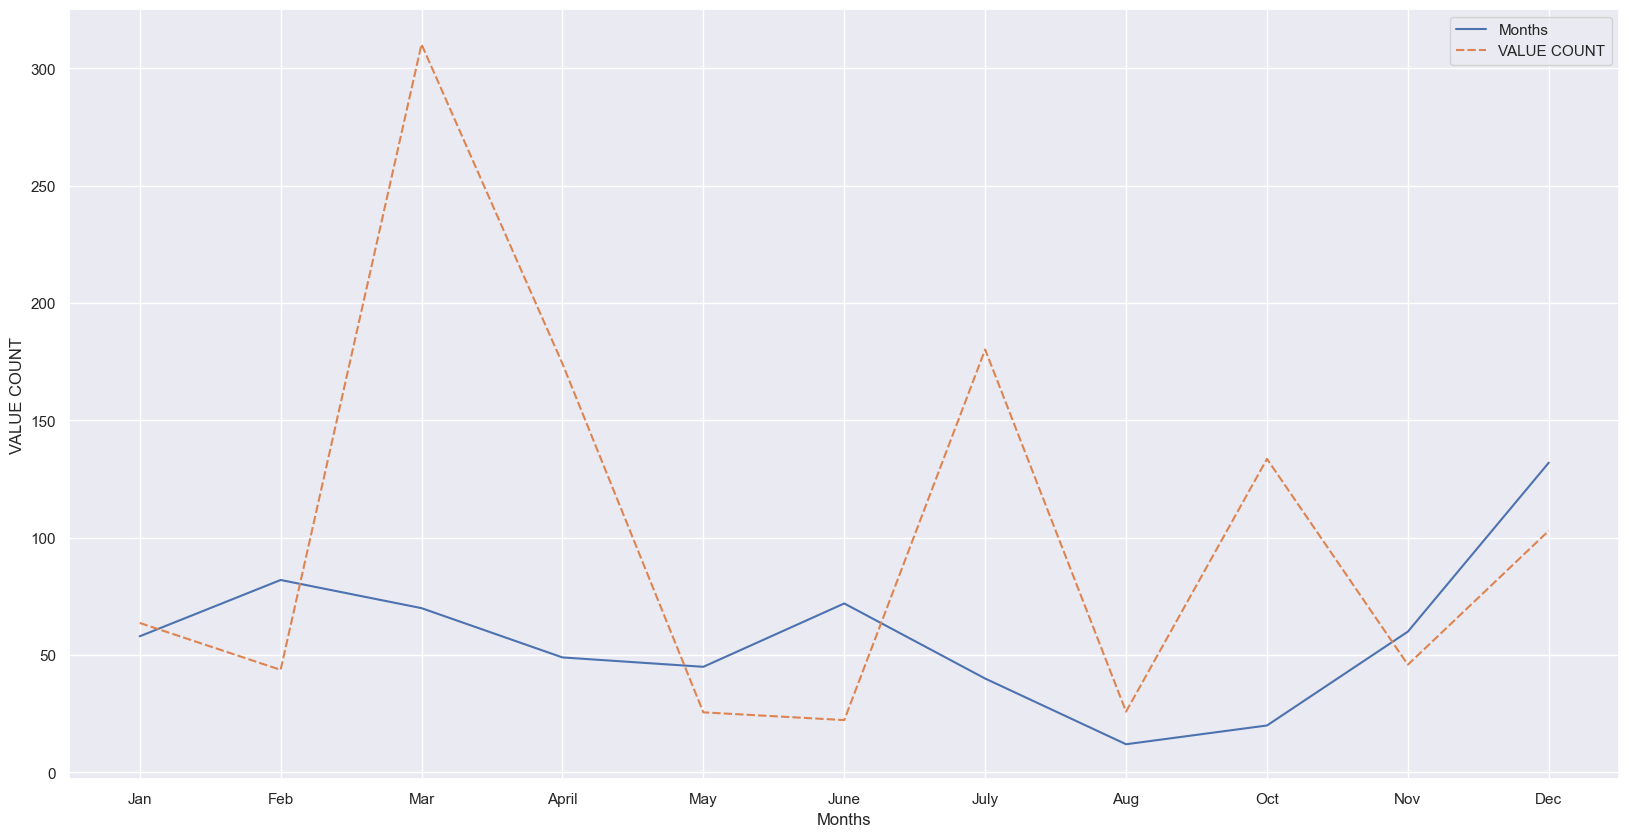

In [139]:
df1 = pd.DataFrame({
 "Months": mon.values, # Har month ka total count.
 "VALUE COUNT": df.groupby('Month', sort=False)['MILES'].max() # Har month ke maax miles ka value
})
p = sns.lineplot(data=df1) # Line plot banata hai.
p.set(xlabel="Months", ylabel="VALUE COUNT") # Axis labels set karta ha

In [140]:
df['Day']=df.START_DATE.dt.weekday

day_label = {
 0: 'Mon', 1:'Tues', 2:'Wed', 3:'Thur',4:'Fri', 5:'Sat', 6:'Sun'}
df['Day'] = df['Day'].map(day_label)

Text(0, 0.5, 'Count')

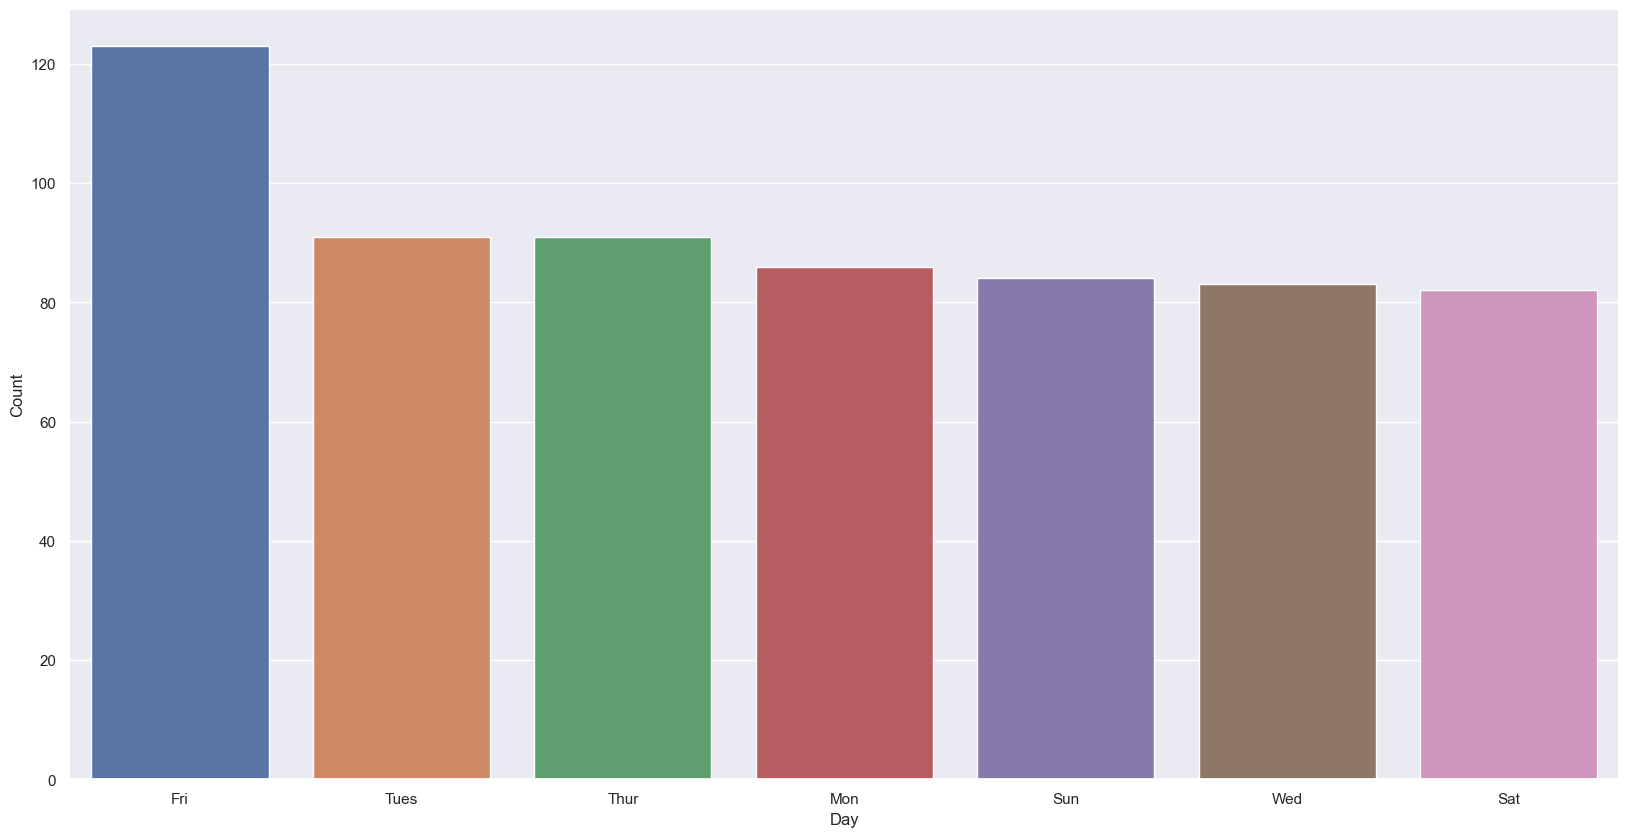

In [141]:
day_label = df.Day.value_counts()

sns.barplot(x=day_label.index,y=day_label)
plt.xlabel("Day")
plt.ylabel("Count")

<Axes: >

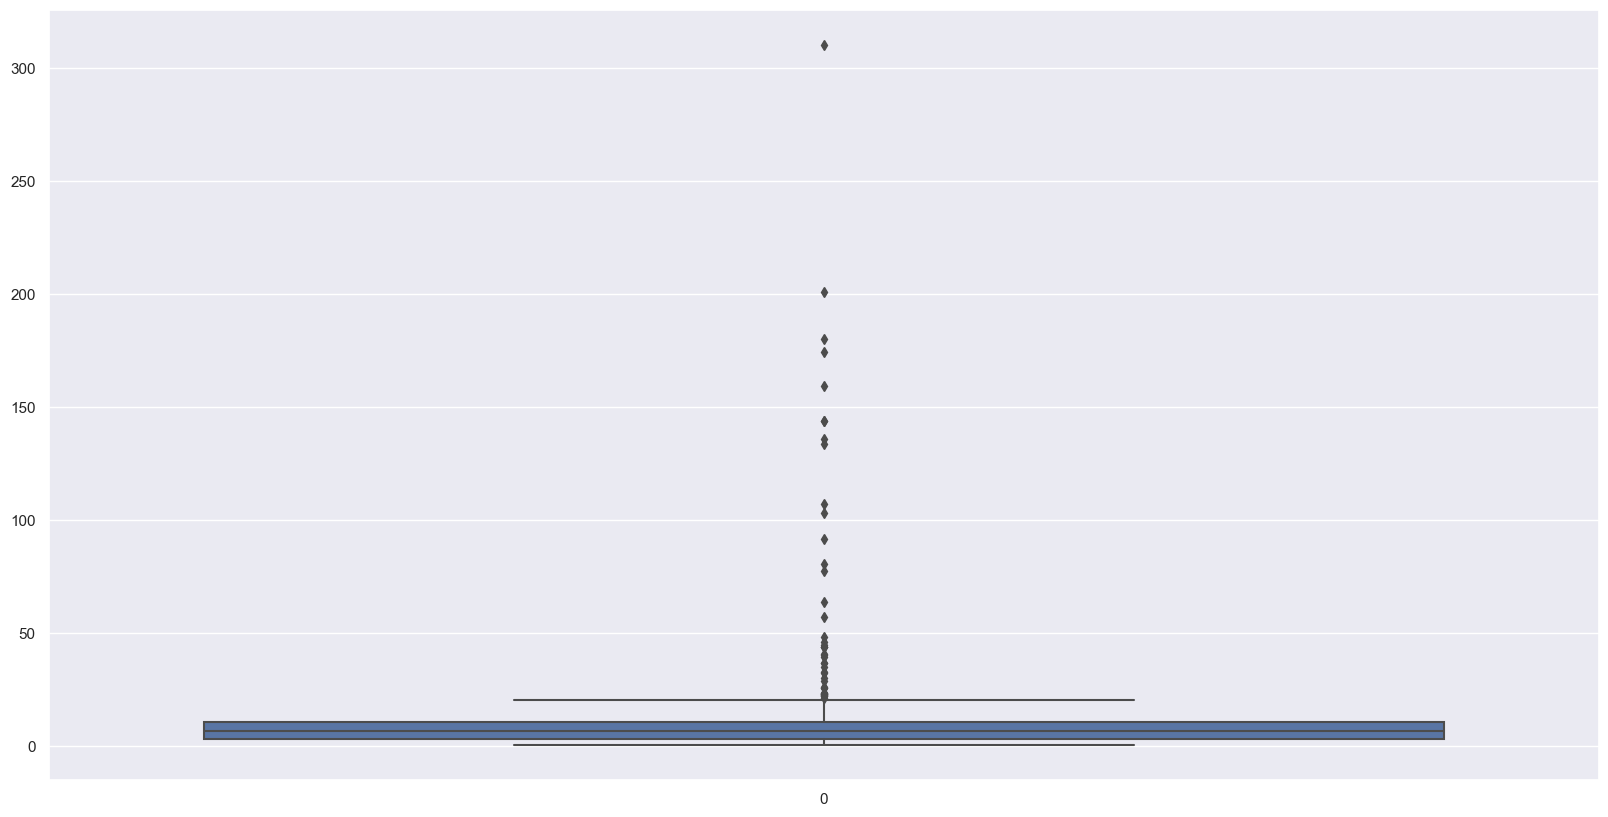

In [142]:
sns.boxplot(df['MILES'])

<Axes: >

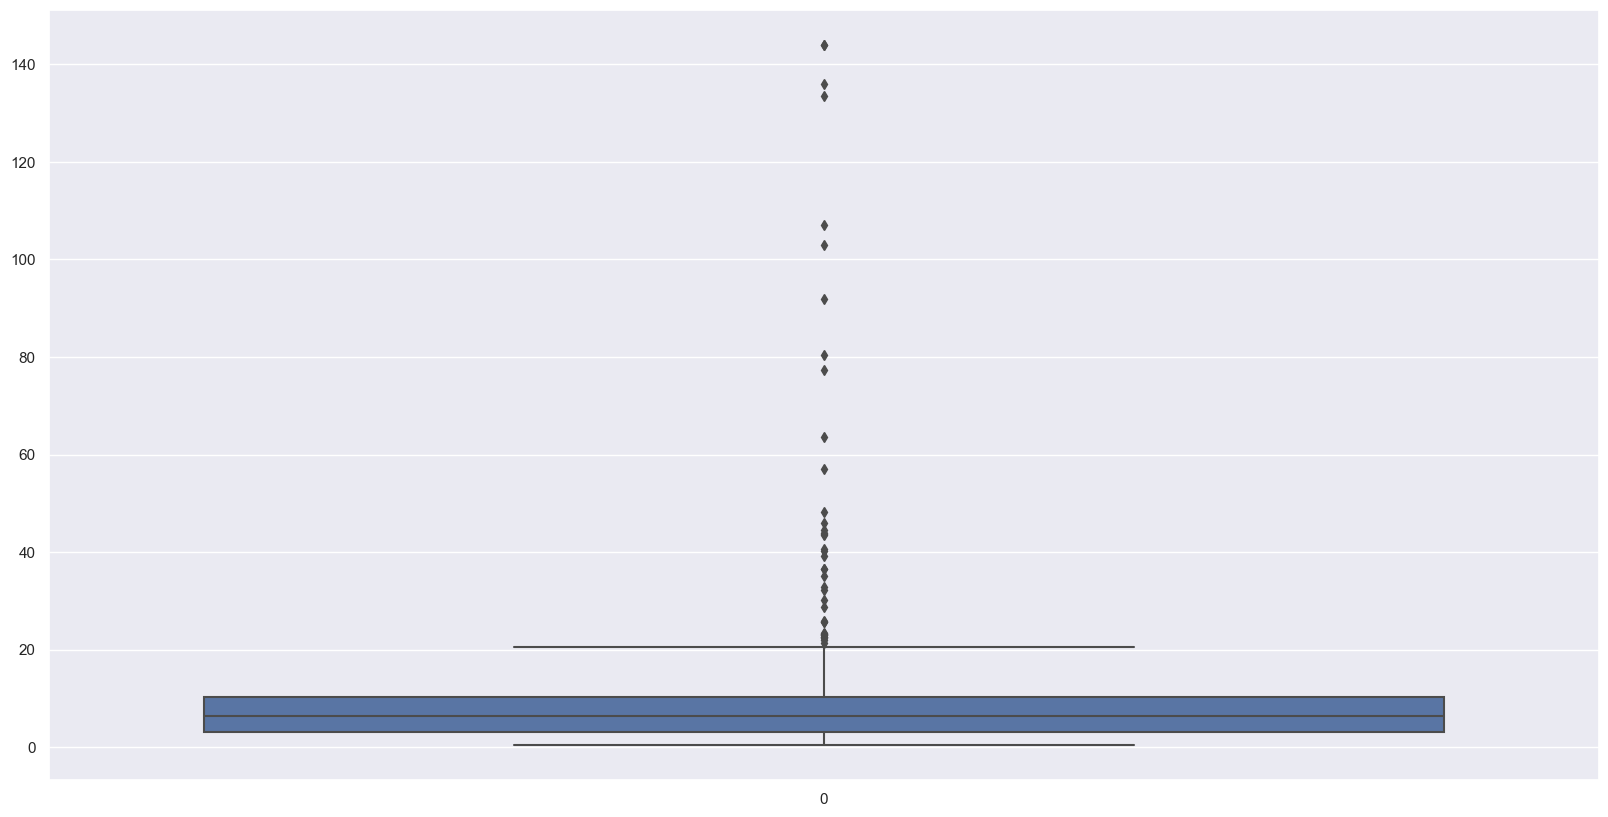

In [143]:
sns.boxplot(df[df['MILES']<150]['MILES'])

<Axes: >

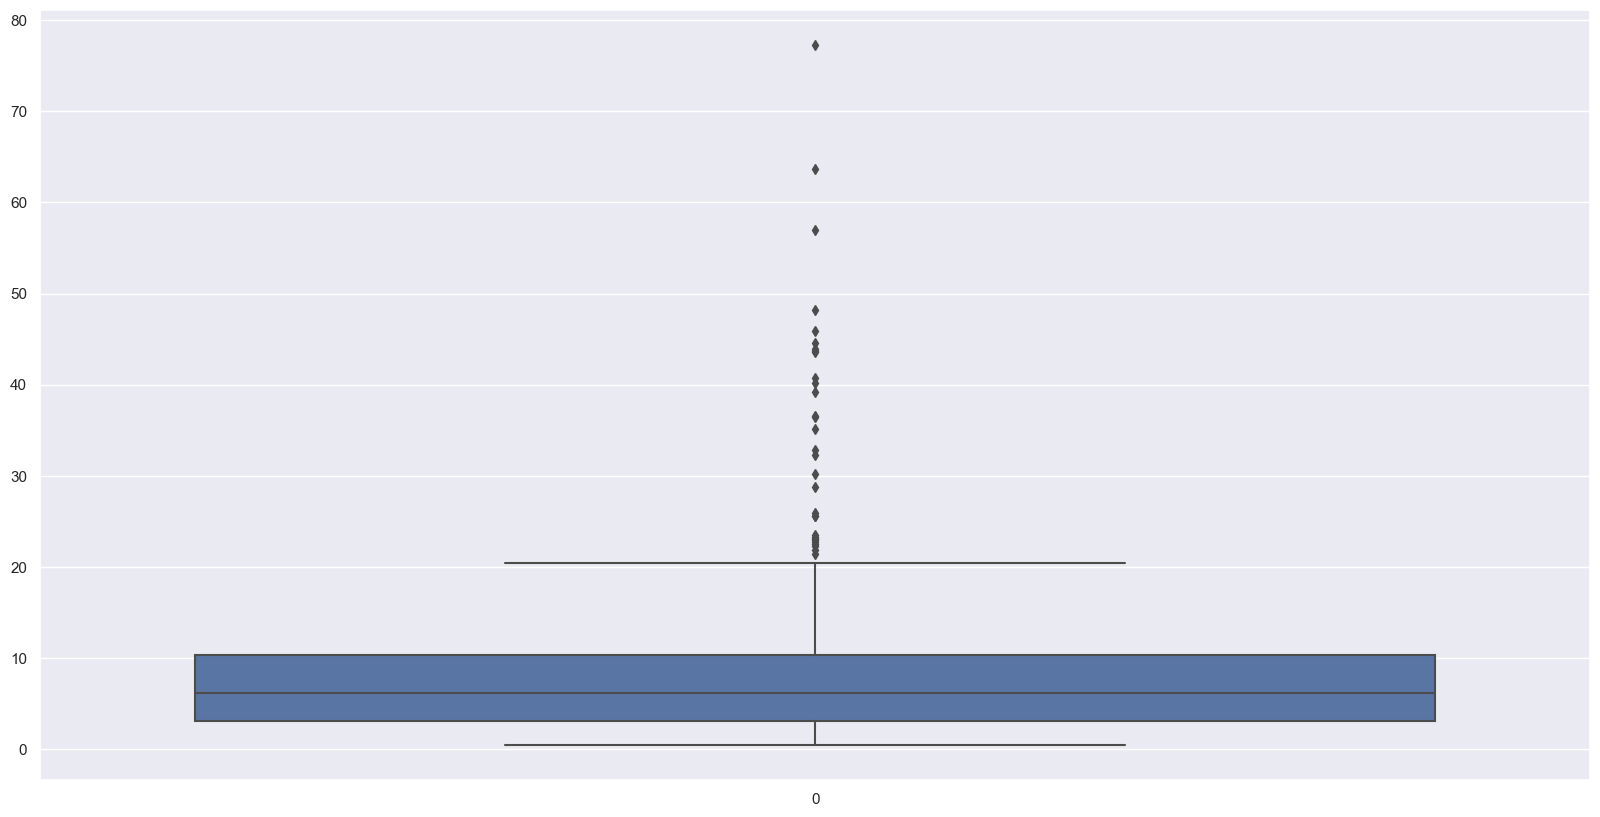

In [144]:
sns.boxplot(df[df['MILES']<80]['MILES'])

C:\Users\foziya khan\AppData\Local\Temp\ipykernel_11840\1171915261.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['MILES']<40]['MILES'])


<Axes: xlabel='MILES', ylabel='Density'>

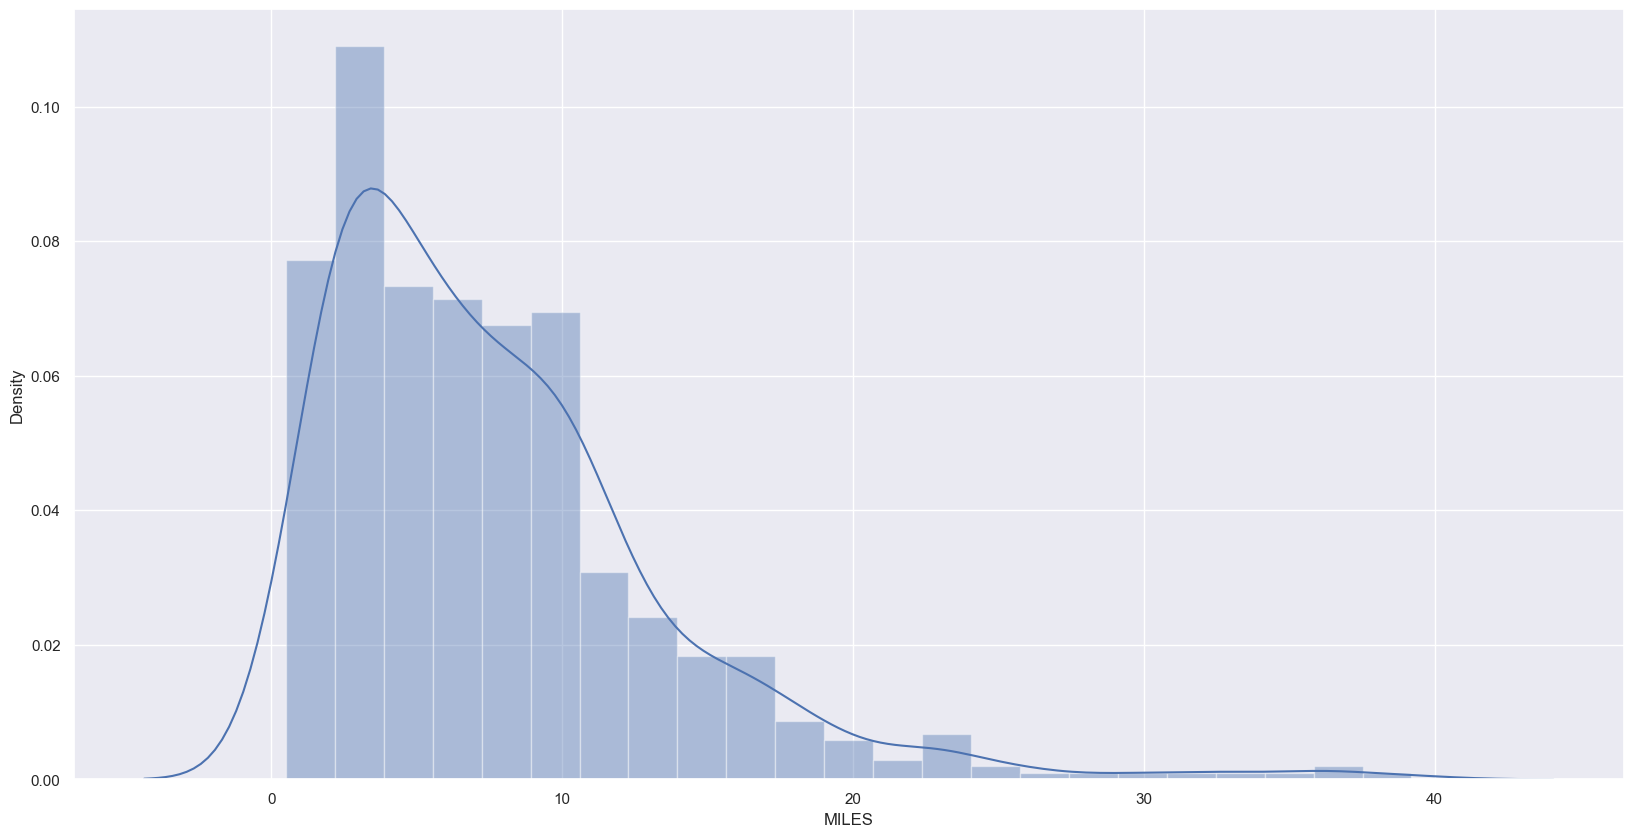

In [146]:
sns.distplot(df[df['MILES']<40]['MILES'])